In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

## Importing and Cleaning Data

In [3]:
df = pd.read_csv('df.csv')

In [60]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [9]:
df = df.drop('CustomerID', axis=1)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [6]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [7]:
df=df.dropna()

In [8]:
df.duplicated().sum()

0

### As we can see, the data is already quite clean and organized, with almost no null or duplicate values.

# EDA

#### Checking churn distribution

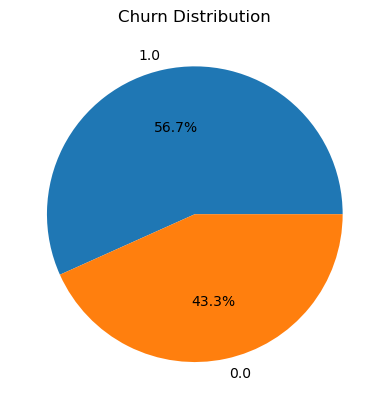

In [13]:
counts = df['Churn'].value_counts()

plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')

plt.title('Churn Distribution')

plt.show()

#### The target variable is slightly imbalanced, with a higher proportion of churned customers (~57%)


#### Distribution of Age

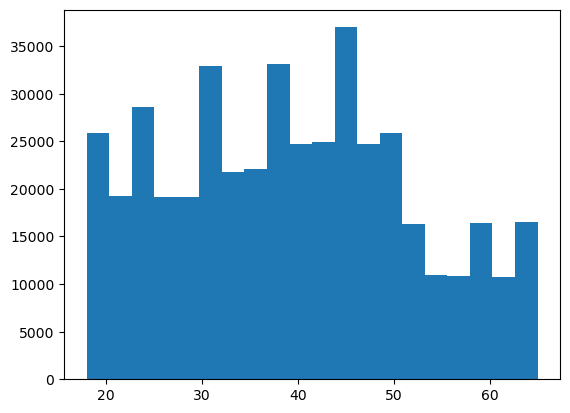

In [16]:
plt.hist(df['Age'], bins=20)
plt.show()

#### Checking outliers on Total Spending and Tenure column

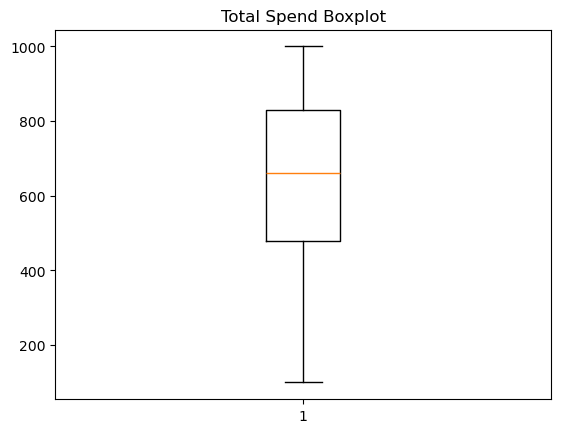

In [18]:
plt.boxplot(df['Total Spend'])
plt.title('Total Spend Boxplot')
plt.show()

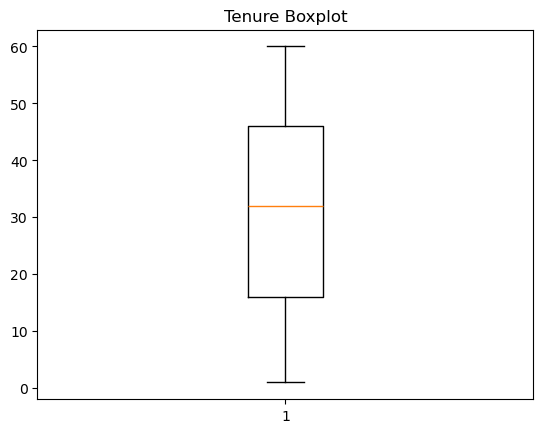

In [19]:
plt.boxplot(df['Tenure'])
plt.title('Tenure Boxplot')
plt.show()

#### Distribution of Subscription Type,Contract Length and Gender


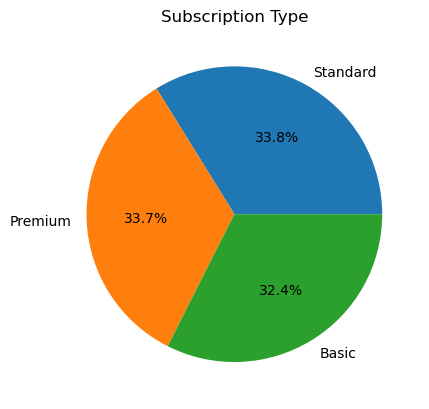

In [21]:
counts_2 = df['Subscription Type'].value_counts()

plt.pie(counts_2.values, labels=counts_2.index, autopct='%1.1f%%')

plt.title('Subscription Type')

plt.show()

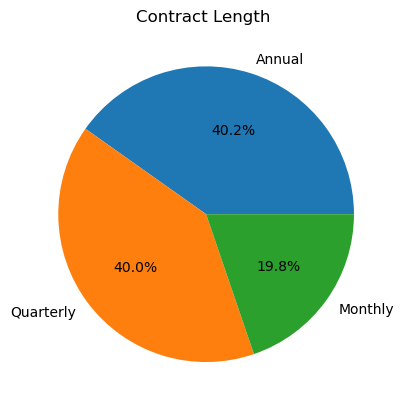

In [22]:
counts_3 = df['Contract Length'].value_counts()

plt.pie(counts_3.values, labels=counts_3.index, autopct='%1.1f%%')

plt.title('Contract Length ')

plt.show()

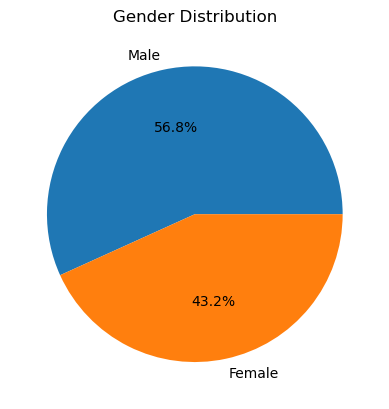

In [23]:
counts_4 = df['Gender'].value_counts()

plt.pie(counts_4.values, labels=counts_4.index, autopct='%1.1f%%')

plt.title('Gender Distribution')

plt.show()

## Exploring Relationship with Churn

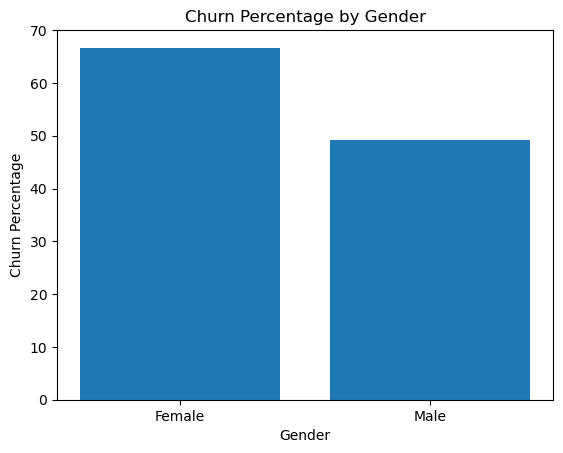

In [25]:
churn_rate = df.groupby('Gender')['Churn'].mean() * 100

plt.bar(churn_rate.index, churn_rate.values)

plt.xlabel('Gender')
plt.ylabel('Churn Percentage')
plt.title('Churn Percentage by Gender')

plt.show()

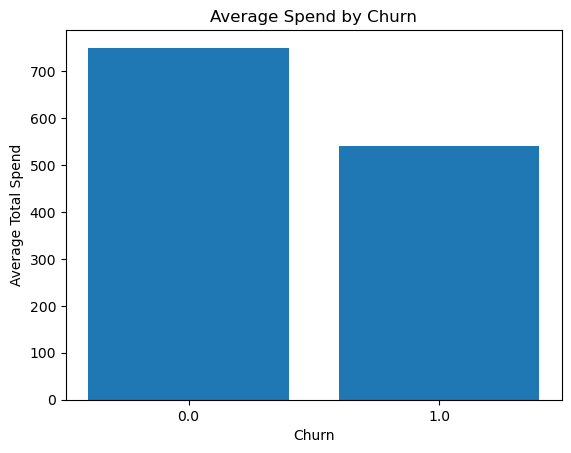

In [26]:
spend = df.groupby('Churn')['Total Spend'].mean()

plt.bar(spend.index.astype(str), spend.values)

plt.xlabel('Churn')
plt.ylabel('Average Total Spend')
plt.title('Average Spend by Churn')

plt.show()

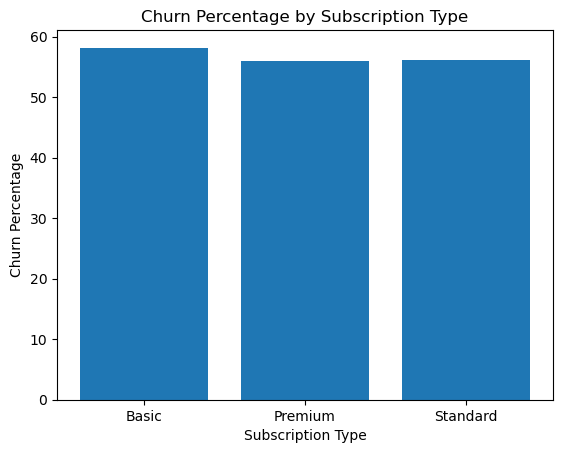

In [47]:
sub_churn = df.groupby('Subscription Type')['Churn'].mean() * 100

plt.bar(sub_churn.index, sub_churn.values)

plt.xlabel('Subscription Type')
plt.ylabel('Churn Percentage')
plt.title('Churn Percentage by Subscription Type')

plt.show()

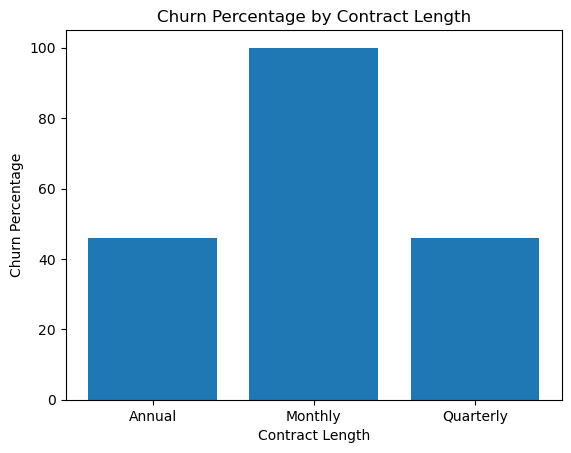

In [49]:
contract_churn = df.groupby('Contract Length')['Churn'].mean() * 100

bars = plt.bar(contract_churn.index, contract_churn.values)

plt.xlabel('Contract Length')
plt.ylabel('Churn Percentage')
plt.title('Churn Percentage by Contract Length')

plt.show()

<Axes: >

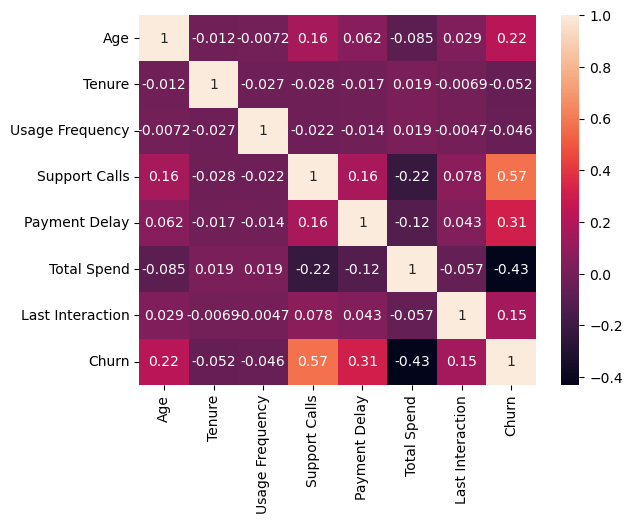

In [27]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

## Observation

## Key Insights

- Female customers have a higher churn percentage compared to male customers.

- Customers who churn tend to spend less overall than retained customers.

- Subscription type does not appear to significantly affect churn.

- Monthly contract subscriptions show the highest churn percentage despite having the lowest customer share.

- Support Calls show the strongest positive correlation with churn, indicating that customers facing more issues are more likely to leave.

## ML

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [220]:
X = df.drop('Churn', axis=1)
y  = df['Churn']

In [88]:
numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [96]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
], remainder='passthrough')

In [102]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier())
])

In [104]:
param_grid = {
    'model__n_estimators': [100, 200,300],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5,10],
    'model__min_samples_leaf': [1, 2,5]
}

In [134]:
model = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
      verbose=3
)

In [136]:
%%time
model.fit(X_train,y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
CPU times: user 36.4 s, sys: 1.78 s, total: 38.2 s
Wall time: 7min 48s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['Gender',
                                                                                'Subscription '
                                                                                'Type',
                                                                                'Contract '
                                                                                'Length'])])),
                                             ('model',
                                              RandomForestClassifier())]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__max_depth': [5, 10, None],
                                        'model__min_samples_leaf': [1, 2, 5],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='accuracy', verbose=3)

In [150]:
tuned_model = model.best_estimator_

In [152]:
tuned_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'Subscription Type',
                                                   'Contract Length'])])),
                ('model', RandomForestClassifier(n_estimators=200))])

In [158]:
predictions = tuned_model.predict(X_test)

In [192]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38063
         1.0       1.00      1.00      1.00     50104

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



In [164]:
tuned_model.score(X_test, y_test)

0.9993081311601847

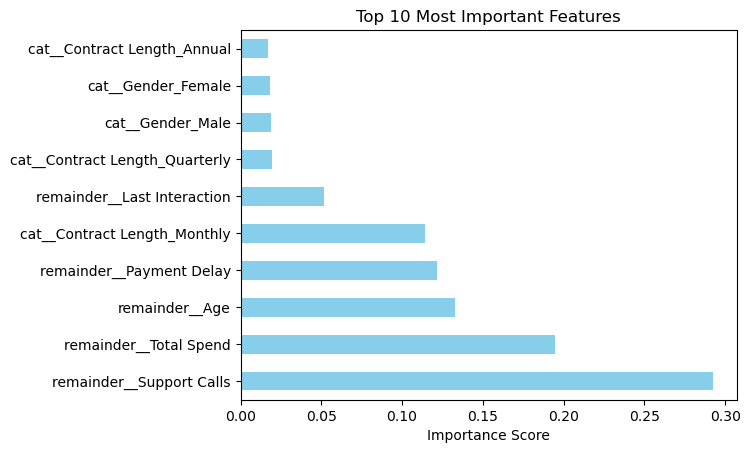

In [174]:
feature_names = tuned_model.named_steps['preprocessor'].get_feature_names_out()
importances = tuned_model.named_steps['model'].feature_importances_
feat_importances = pd.Series(importances, index=feature_names)
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.show()

## Business Insights & Recommendations

### 1. Customer Support as Churn Trigger
**Insight:** Support Calls is a key leading indicator of churn, suggesting unresolved issues drive cancellations.  
**Action:** Flag users with 3+ support calls/month for proactive “High-Touch” intervention.

---

### 2. Price Sensitivity & Value Perception
**Insight:** Higher Total Spend correlates with churn, indicating perceived low ROI among high-value users.  
**Action:** Introduce loyalty tiers and long-term value benefits (discounts, perks) for high-spending customers.

---



## Testing on entire different dataset

In [243]:
test = pd.read_csv('df1.csv')

In [245]:
X_test_2 = df.drop('Churn', axis=1)
y_2  = df['Churn']

In [247]:
tuned_model.score(X_test_2,y_2)

0.9791553244773519

In [249]:
print(classification_report(y_2,tuned_model.predict(X_test_2)))

              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98    190833
         1.0       1.00      0.96      0.98    249999

    accuracy                           0.98    440832
   macro avg       0.98      0.98      0.98    440832
weighted avg       0.98      0.98      0.98    440832

